# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *Elias Hawkins*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [3]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: elias050
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:05<00:00, 75.6MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [4]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [5]:
# Your exploration here
class_names = train_raw_fire.class_names
print("Class names:", class_names)

Class names: ['fire_images', 'non_fire_images']


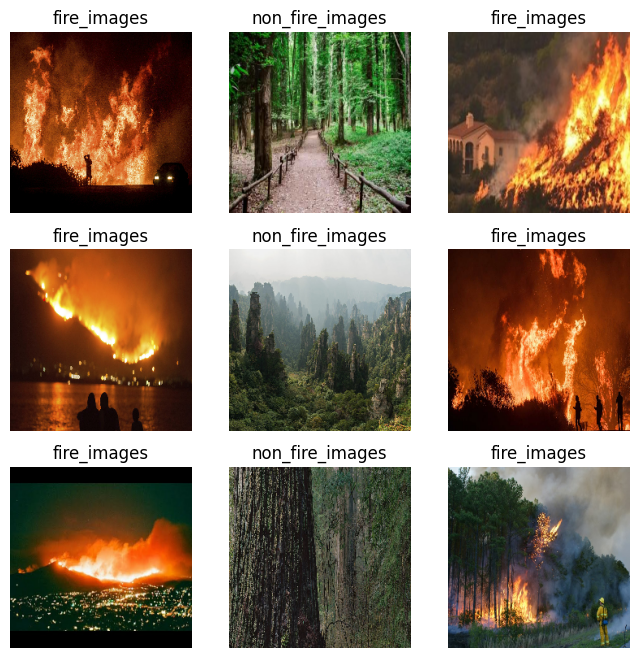

In [6]:
# I wanted to look at the actual images before proceeding.
class_names = train_raw_fire.class_names

plt.figure(figsize=(8, 8))
for images, labels in train_raw_fire.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

**Answer**: I will probably use an sigmoid activation function and an output function of binary classification since our model will practically be predicting a yes/no style question.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [7]:
# Preprocess the data here

# Preprocess training data (image, label)
def preprocess_mobilenet(image, label):
  return preprocess_input(image), label

train_ds_mobilenet = train_raw_fire.map(preprocess_mobilenet)
val_ds_mobilenet = val_raw_fire.map(preprocess_mobilenet)

# Preprocess test data (images and labels)
def preprocess_test_mobilenet(image, label):
  return preprocess_input(image), label

test_ds_mobilenet = test_raw_fire.map(preprocess_test_mobilenet)

In [8]:
# Build your model here
base_model_mobilenet = MobileNetV2(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
base_model_mobilenet.trainable = False      # Freeze the base

x = base_model_mobilenet.output
y = GlobalAveragePooling2D()(x)

# For binary classification, use 1 output unit with a sigmoid activation
output = Dense(1, activation="sigmoid")(y)

mobilenet_model = Model(inputs=base_model_mobilenet.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
# Compile your model here
mobilenet_model.compile(optimizer="adam",
                        loss="binary_crossentropy",
                        metrics=["accuracy"])

mobilenet_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [10]:
# Train your model here
mobilenet_history = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7314 - loss: 0.4923 - val_accuracy: 0.8993 - val_loss: 0.2822
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9543 - loss: 0.1862 - val_accuracy: 0.9640 - val_loss: 0.1522
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9700 - loss: 0.1203 - val_accuracy: 0.9568 - val_loss: 0.1238
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9771 - loss: 0.0964 - val_accuracy: 0.9712 - val_loss: 0.0864
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9786 - loss: 0.0830 - val_accuracy: 0.9856 - val_loss: 0.0736


In [11]:
# Report validation and test accuracy here
mobilenet_val_loss, mobilenet_val_acc = mobilenet_model.evaluate(val_ds_mobilenet)
print(f"MobileNetV2 -- Validation Accuracy: {mobilenet_val_acc:.3f}")

mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(test_ds_mobilenet)
print(f"MobileNetV2 -- Test Accuracy: {mobilenet_test_acc:.3f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 830ms/step - accuracy: 0.9640 - loss: 0.0914
MobileNetV2 -- Validation Accuracy: 0.964
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.9750 - loss: 0.0801
MobileNetV2 -- Test Accuracy: 0.975


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

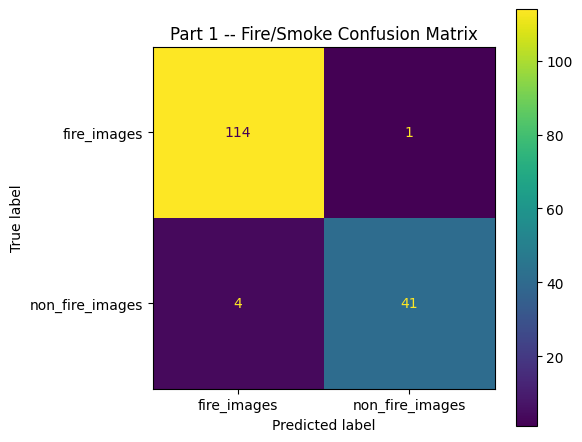

In [12]:
# Build your confusion matrix here.
fire_cm_ds = test_raw_fire.map(lambda image, label: (preprocess_input(image), label))

y_true_fire_batches = []
y_pred_fire_batches = []
for images, labels in fire_cm_ds:
    y_true_fire_batches.append(labels.numpy().reshape(-1))
    probs = mobilenet_model(images, training=False).numpy()  # shape (batch, 1)
    y_pred_fire_batches.append((probs.ravel() >= 0.5).astype(int))

y_true_fire = np.concatenate(y_true_fire_batches)
y_pred_fire = np.concatenate(y_pred_fire_batches)

cm_fire = confusion_matrix(
    y_true_fire, y_pred_fire, labels=np.arange(len(class_names_fire))
)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_fire, display_labels=class_names_fire
).plot(ax=ax)
ax.set_title("Part 1 -- Fire/Smoke Confusion Matrix")
plt.tight_layout()
plt.show()

*Your answer:* A false negative (missing a real fire) is more costly. Because of this, I would lower the decision threshold so that there would be less false negatives determined.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [13]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [14]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [15]:
# Preprocess the data here

# Preprocess training data (image, label)
def preprocess_mobilenet(image, label):
  return preprocess_input(image), label

train_ds_mobilenet_sat = train_raw_sat.map(preprocess_mobilenet)
val_ds_mobilenet_sat = val_raw_sat.map(preprocess_mobilenet)

# Preprocess test data (images and labels)
def preprocess_test_mobilenet(image, label):
  return preprocess_input(image), label

test_ds_mobilenet_sat = test_raw_sat.map(preprocess_test_mobilenet)


In [16]:
# Build your model here
base_model_sat = MobileNetV2(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
base_model_sat.trainable = False        # Freeze the base

x = base_model_sat.output
y = GlobalAveragePooling2D()(x)

output = Dense(len(class_names_sat), activation="softmax")(y)   # 10 units, softmax

sat_model = Model(inputs=base_model_sat.input, outputs=output)

In [17]:
# Compile your model here
sat_model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

sat_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [18]:
# Train your model here
sat_history = sat_model.fit(
    train_ds_mobilenet_sat,
    validation_data=val_ds_mobilenet_sat,
    epochs=3
)

Epoch 1/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 822s 1s/step - accuracy: 0.8801 - loss: 0.3722 - val_accuracy: 0.9279 - val_loss: 0.2227
Epoch 2/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 860s 1s/step - accuracy: 0.9334 - loss: 0.1958 - val_accuracy: 0.9321 - val_loss: 0.1957
Epoch 3/3
591/591 ━━━━━━━━━━━━━━━━━━━━ 799s 1s/step - accuracy: 0.9466 - loss: 0.1595 - val_accuracy: 0.9381 - val_loss: 0.1832


In [19]:
# Report validation and test accuracy here
mobilenet_val_loss_sat, mobilenet_val_acc_sat = sat_model.evaluate(val_ds_mobilenet_sat)
print(f"MobileNetV2 -- Validation Accuracy: {mobilenet_val_acc_sat:.3f}")

mobilenet_test_loss_sat, mobilenet_test_acc_sat = sat_model.evaluate(test_ds_mobilenet_sat)
print(f"MobileNetV2 -- Test Accuracy: {mobilenet_test_acc_sat:.3f}")

127/127 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9383 - loss: 0.1852
MobileNetV2 -- Validation Accuracy: 0.938
127/127 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9370 - loss: 0.1901
MobileNetV2 -- Test Accuracy: 0.937


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

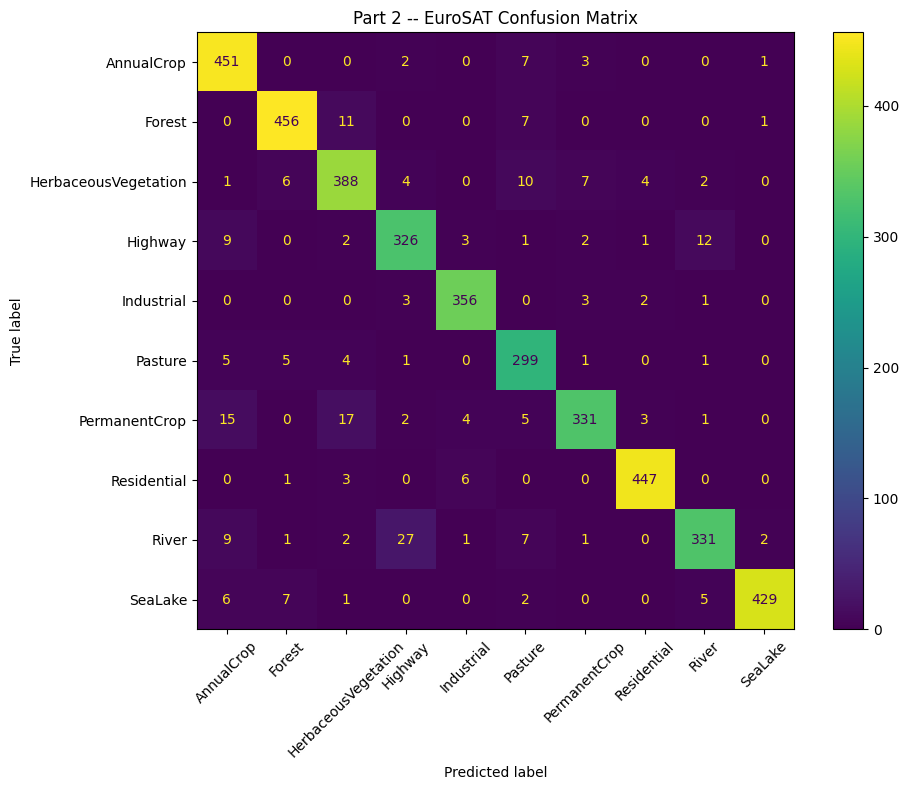

In [20]:
# Build your confusion matrix here.
sat_cm_ds = test_raw_sat.map(lambda image, label: (preprocess_input(image), label))

y_true_sat_batches = []
y_pred_sat_batches = []
for images, labels in sat_cm_ds:
    y_true_sat_batches.append(labels.numpy().reshape(-1))
    probs = sat_model(images, training=False).numpy()  # shape (batch, 10)
    y_pred_sat_batches.append(np.argmax(probs, axis=1))

y_true_sat = np.concatenate(y_true_sat_batches)
y_pred_sat = np.concatenate(y_pred_sat_batches)

cm_sat = confusion_matrix(
    y_true_sat, y_pred_sat, labels=np.arange(len(class_names_sat))
)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=cm_sat, display_labels=class_names_sat
).plot(ax=ax, xticks_rotation=45)
ax.set_title("Part 2 -- EuroSAT Confusion Matrix")
plt.tight_layout()
plt.show()

*Your answer:* River and Highway get mixed up the most. 27 rivers were called Highway, and 12 highways were called River. PermanentCrop also gets confused with HerbaceousVegetation and AnnualCrop. That makes sense to me, since a river and a road both look like thin lines from above, and those crop and vegetation classes all look like fields.


---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 96% | 94% |
| Test Accuracy | 98% | 94% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1. Fire/smoke is the closer match to ImageNet. Those are normal ground-level photos, and the test accuracy was about 98%. EuroSAT is the bigger mismatch because the pictures are taken from overhead, and the test accuracy was about 94%.
2. Unfreezing part of the base would matter more for EuroSAT. The fire model was already about 98% with the base frozen and only missed a few images, so changing the pretrained layers would not add much. EuroSAT still mixes up classes that look similar from above, and ImageNet never trained on that kind of view, so adjusting the base would help more there.


---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The fire dataset is unbalanced, 755 fire images and only 244 non-fire images, so a high accuracy can just mean the model keeps predicting fire. That is why the confusion matrix matters more than the accuracy number for this set. Part 1 uses one sigmoid output and binary crossentropy because it is a yes or no decision. Part 2 uses 10 softmax outputs and sparse categorical crossentropy because there are 10 classes and the labels are integers. The same MobileNetV2 got about 98% test accuracy on the fire photos and about 94% on EuroSAT, so how close ImageNet is to the new task shows up in the results.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.